In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('test_data.csv')

In [3]:
data.head()

,city,time,date,group,status,order
0,test_city,2018-09-19 01:51:22,2018-09-19,control,done,986433844
1,test_city,2018-09-11 12:58:52,2018-09-11,control,done,962139982
2,test_city,2018-09-20 07:33:07,2018-09-20,control,done,989841412
3,test_city,2018-09-12 15:37:36,2018-09-12,test,done,965664196
4,test_city,2018-09-19 08:31:06,2018-09-19,control,canceled,986948440


In [4]:
# Смотрю что по нанам - есть наны в статусах - это мегаважная для нас информация, поэтому просто вырежу эти строки
data[data.isna().any(axis=1)]

,city,time,date,group,status,order
28386,test_city,2018-08-23 13:59:54,2018-08-23,test,NaN,891774076
37575,test_city,2018-08-23 13:59:59,2018-08-23,control,NaN,891774010
43621,test_city,2018-08-23 13:59:48,2018-08-23,test,NaN,891775996
62750,test_city,2018-09-20 13:57:29,2018-09-20,test,NaN,990925030
91823,test_city,2018-09-20 13:59:57,2018-09-20,control,NaN,990920434
144204,test_city,2018-09-06 14:09:28,2018-09-06,control,NaN,948362302
155189,test_city,2018-09-20 13:59:56,2018-09-20,control,NaN,990919948
232025,test_city,2018-09-06 14:03:00,2018-09-06,test,NaN,948458152
258643,test_city,2018-09-06 15:15:01,2018-09-06,test,NaN,948455974
263420,test_city,2018-09-20 13:59:35,2018-09-20,test,NaN,990921202


In [5]:
data = data[data['status'].notna()]

In [6]:
# Тут смотрю размеры групп, чтобы понять дизайн теста - 50/50 или что-то другое
data.groupby('group')['status'].count()

group
control    652967
test       660732
Name: status, dtype: int64

In [7]:
# Посмотрим какие статусы в принципе есть
data.groupby(['group', 'status'])['status'].count()

group    status                      
control  canceled                        176372
         canceled_by_preauthorization     14104
         done                            462491
test     canceled                        171275
         canceled_by_preauthorization     14399
         done                            475058
Name: status, dtype: int64

## Нулевая итерация

In [8]:
from IPython.display import Image

Вот так буду считать статзначимость

v1 - контрольная группа

v2 - тестовая группа

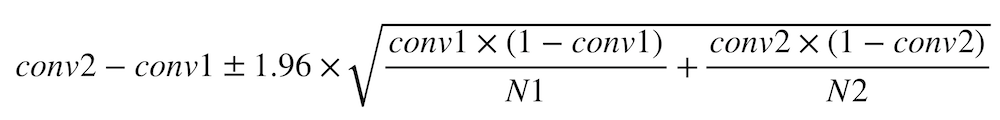

In [9]:
Image('CI.png')

In [10]:
def confidence_interval(conv1, conv2, N1, N2):
    left = conv2 - conv1 - 1.96 * np.sqrt(conv1*(1-conv1)/N1 + conv2*(1-conv2)/N2)
    right = conv2 - conv1 + 1.96 * np.sqrt(conv1*(1-conv1)/N1 + conv2*(1-conv2)/N2)
    return [left, right]

In [11]:
params = {
    'conv1': data.groupby(['group', 'status'])['status'].count()['control']['done'] / data.groupby('group')['status'].count()['control'],
    'conv2': data.groupby(['group', 'status'])['status'].count()['test']['done'] / data.groupby('group')['status'].count()['test'],
    'N1': data.groupby('group')['status'].count()['control'],
    'N2': data.groupby('group')['status'].count()['test']
}

In [12]:
confidence_interval(**params)

[0.009149831477045805, 0.01224194678002048]

Вывод: доверительный интервал не содержит нуля, а значения > 0 -> конверсия в тестовой группе статзначимо выше контрольной - Катим!

## Вторая итерация - задаем вопросы

### 1. Canceled with preauthorization
МБ есть заказы, где сначала был присвоен статус canceled*, а потом done - например, оплата по карте не прошла, потом клиент оплатил с другой карты. Такие заказы надо будет обработать, чтобы они не занижали конверсию

In [13]:
data.groupby('group').order.nunique()

group
control    652964
test       660732
Name: order, dtype: int64

In [14]:
data.groupby('group').order.count()

group
control    652967
test       660732
Name: order, dtype: int64

Вывод: парочка таких заказов есть, но на таких объемах это не повлияет

### 2. Сезонность?
Мб группы были разнесены по времени - тогда доверительный интервал ничего не скажет, потому что могла повлиять сезонность

Text(0.5, 1.0, 'Количество выполненных заказов по дням теста')

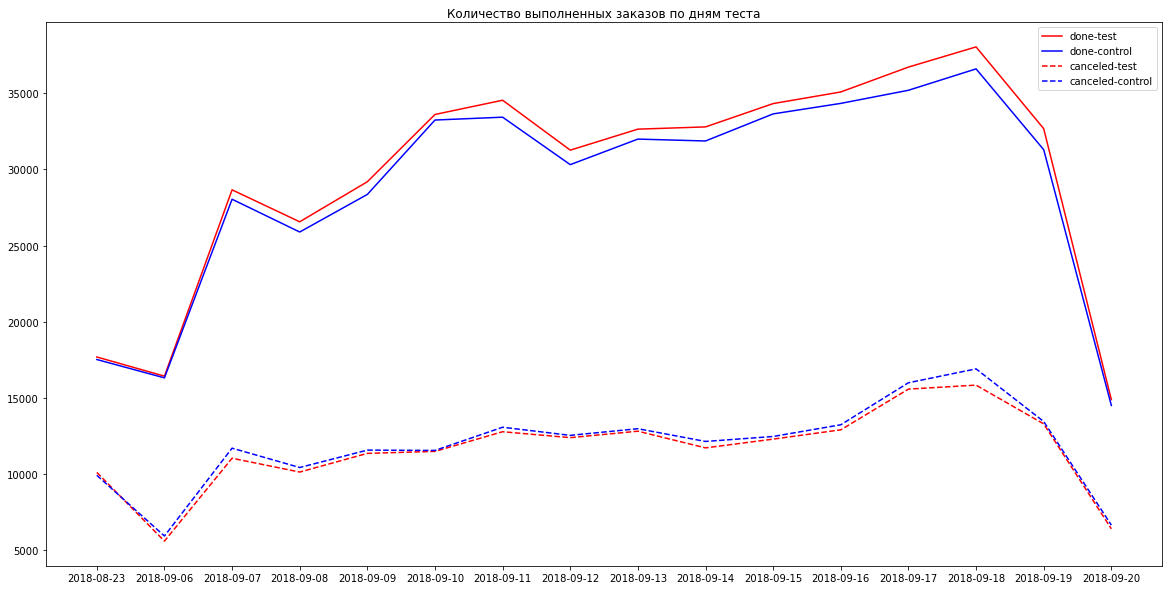

In [22]:
fig, axes = plt.subplots(figsize=(20, 10))

axes.plot(data[data.status == 'done'].groupby(['group', 'date'])['status'].count()['test'], 'r', label='done-test')
axes.plot(data[data.status == 'done'].groupby(['group', 'date'])['status'].count()['control'], 'b', label='done-control')

axes.plot(data[data.status != 'done'].groupby(['group', 'date'])['status'].count()['test'], 'r--', label='canceled-test')
axes.plot(data[data.status != 'done'].groupby(['group', 'date'])['status'].count()['control'], 'b--', label='canceled-control')

axes.legend()
axes.set_title('Количество выполненных заказов по дням теста')

Временные промежутки одинаковые - все ОК. 

Text(0.5, 1.0, 'Исполняемость по дням теста')

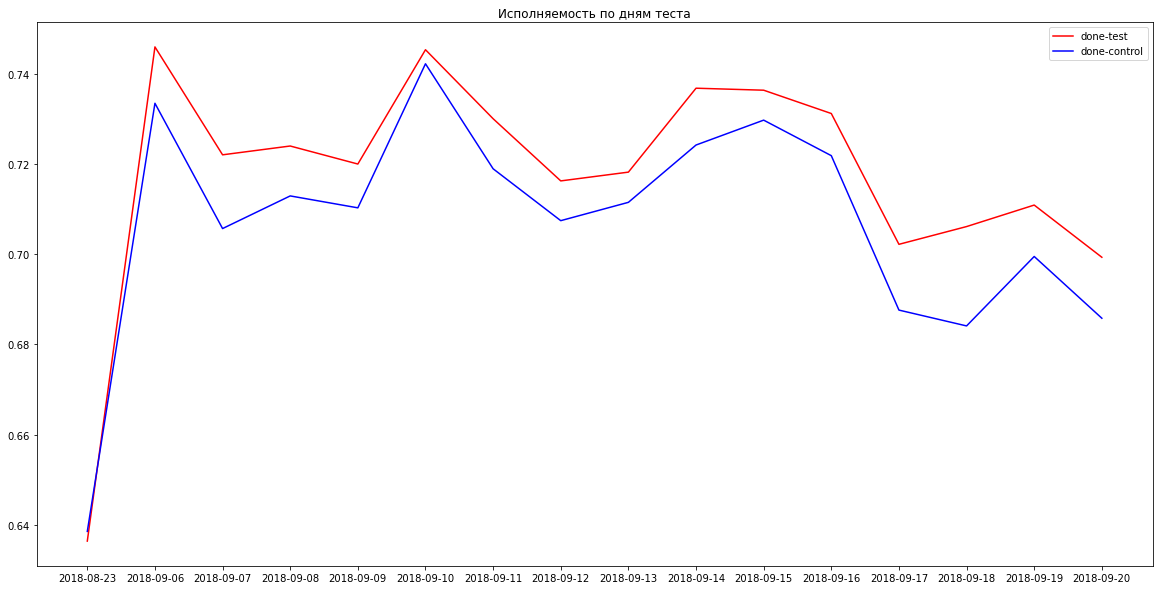

In [21]:
fig, axes = plt.subplots(figsize=(20, 10))

axes.plot(data[data.status == 'done'].groupby(['group', 'date'])['status'].count()['test'] / data.groupby(['group', 'date'])['status'].count()['test'], 'r', label='done-test')
axes.plot(data[data.status == 'done'].groupby(['group', 'date'])['status'].count()['control'] / data.groupby(['group', 'date'])['status'].count()['control'], 'b', label='done-control')

axes.legend()
axes.set_title('Исполняемость по дням теста')

### 2. 2018-08-23?
Какой-то прикол с 2018-08-23: конверсия сильно ниже и после этой даты две недели нет данных. Мб какие-то тестовые записи попали? Гляну доверительный интервал без учета этой даты

In [17]:
data_cutted = data[data.date > '2018-08-23']
params_2 = {
    'conv1': data_cutted.groupby(['group', 'status'])['status'].count()['control']['done'] / data_cutted.groupby('group')['status'].count()['control'],
    'conv2': data_cutted.groupby(['group', 'status'])['status'].count()['test']['done'] / data_cutted.groupby('group')['status'].count()['test'],
    'N1': data_cutted.groupby('group')['status'].count()['control'],
    'N2': data_cutted.groupby('group')['status'].count()['test']
}

In [18]:
confidence_interval(**params_2)

[0.009689016570082006, 0.012837074864302992]

Выводы не изменились. Но заметил странную просадку в количестве поездок 6 и 20 сентября - это сезонность или просто не весь день держали тест?

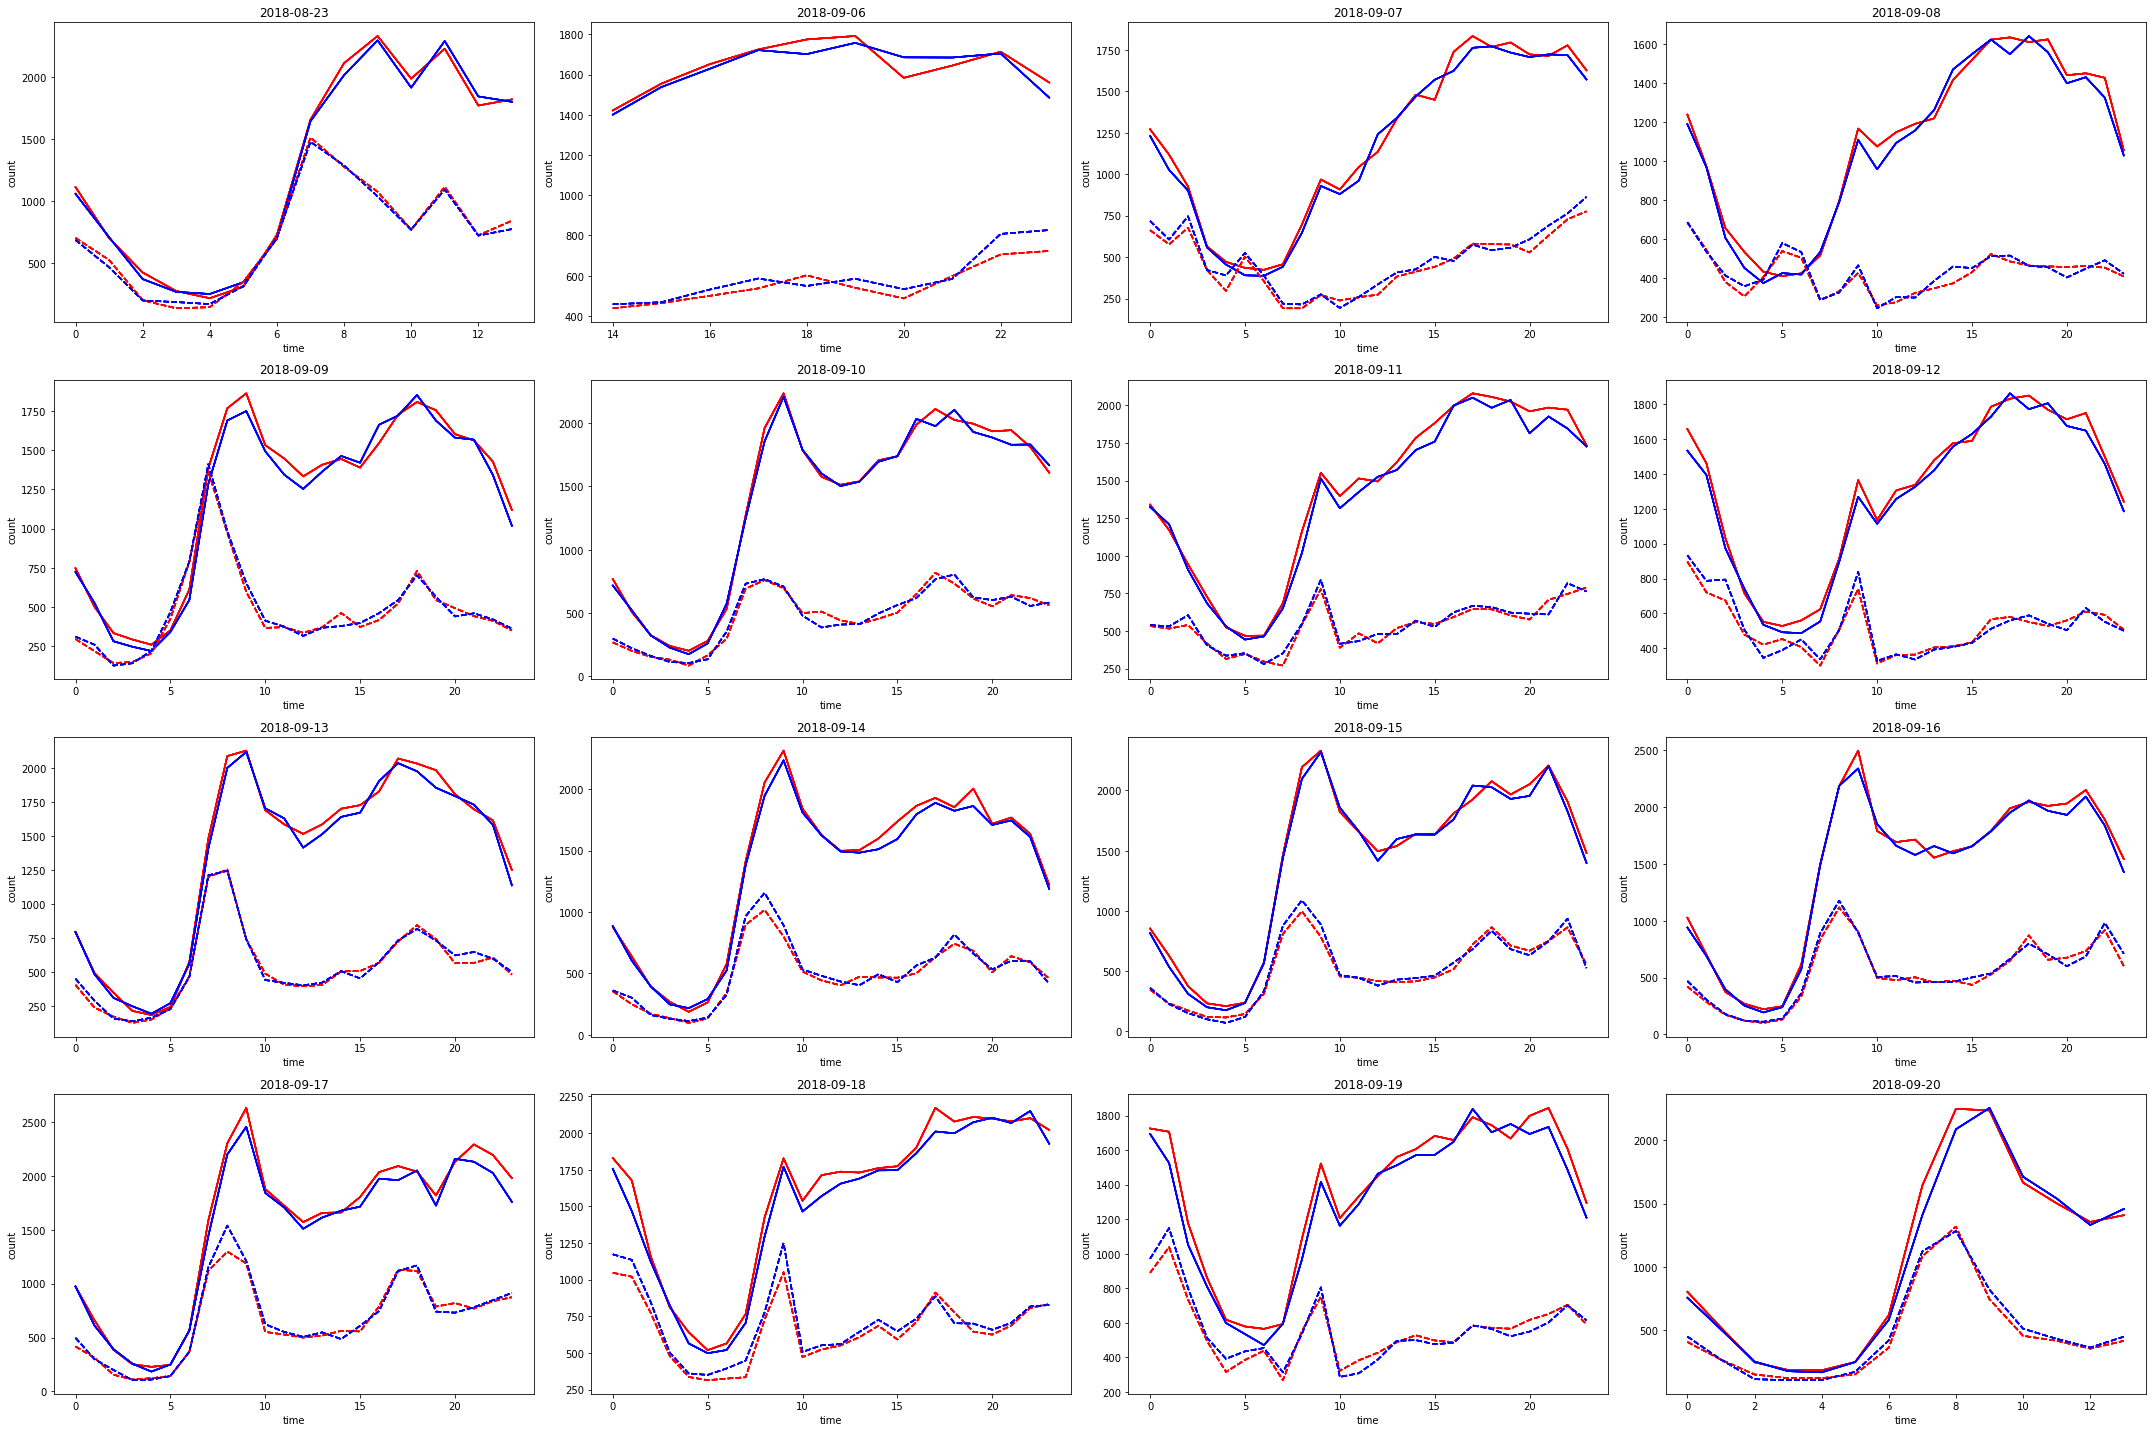

In [19]:
days = data['date'].unique()
days.sort()

data['time'] = pd.to_datetime(data['time'])
data['hours'] = data['time'].dt.hour

fig, axes = plt.subplots(figsize=(30, 20), nrows=4, ncols=4)

for ax, day in zip(axes.flatten(), days):
    ax.plot(data[(data.status == 'done') 
                 & (data.date == day) 
                & (data.group == 'test')].groupby('hours').count(), 'r', label='done-test')
    ax.plot(data[(data.status == 'done') 
                 & (data.date == day) 
                & (data.group == 'control')].groupby('hours').count(), 'b', label='done-control')
    ax.plot(data[(data.status != 'done') 
                 & (data.date == day) 
                & (data.group == 'test')].groupby('hours').count(), 'r--', label='canceled-test')
    ax.plot(data[(data.status != 'done') 
                 & (data.date == day) 
                & (data.group == 'control')].groupby('hours').count(), 'b--', label='canceled-control')
    ax.set_xlabel('time')
    ax.set_ylabel('count')
    ax.set_title('{}'.format(day))

fig.tight_layout()

# axes.legend()

Окей, понял. Тест запустили 6 сентября после обеда, а закончили 20 в час дня

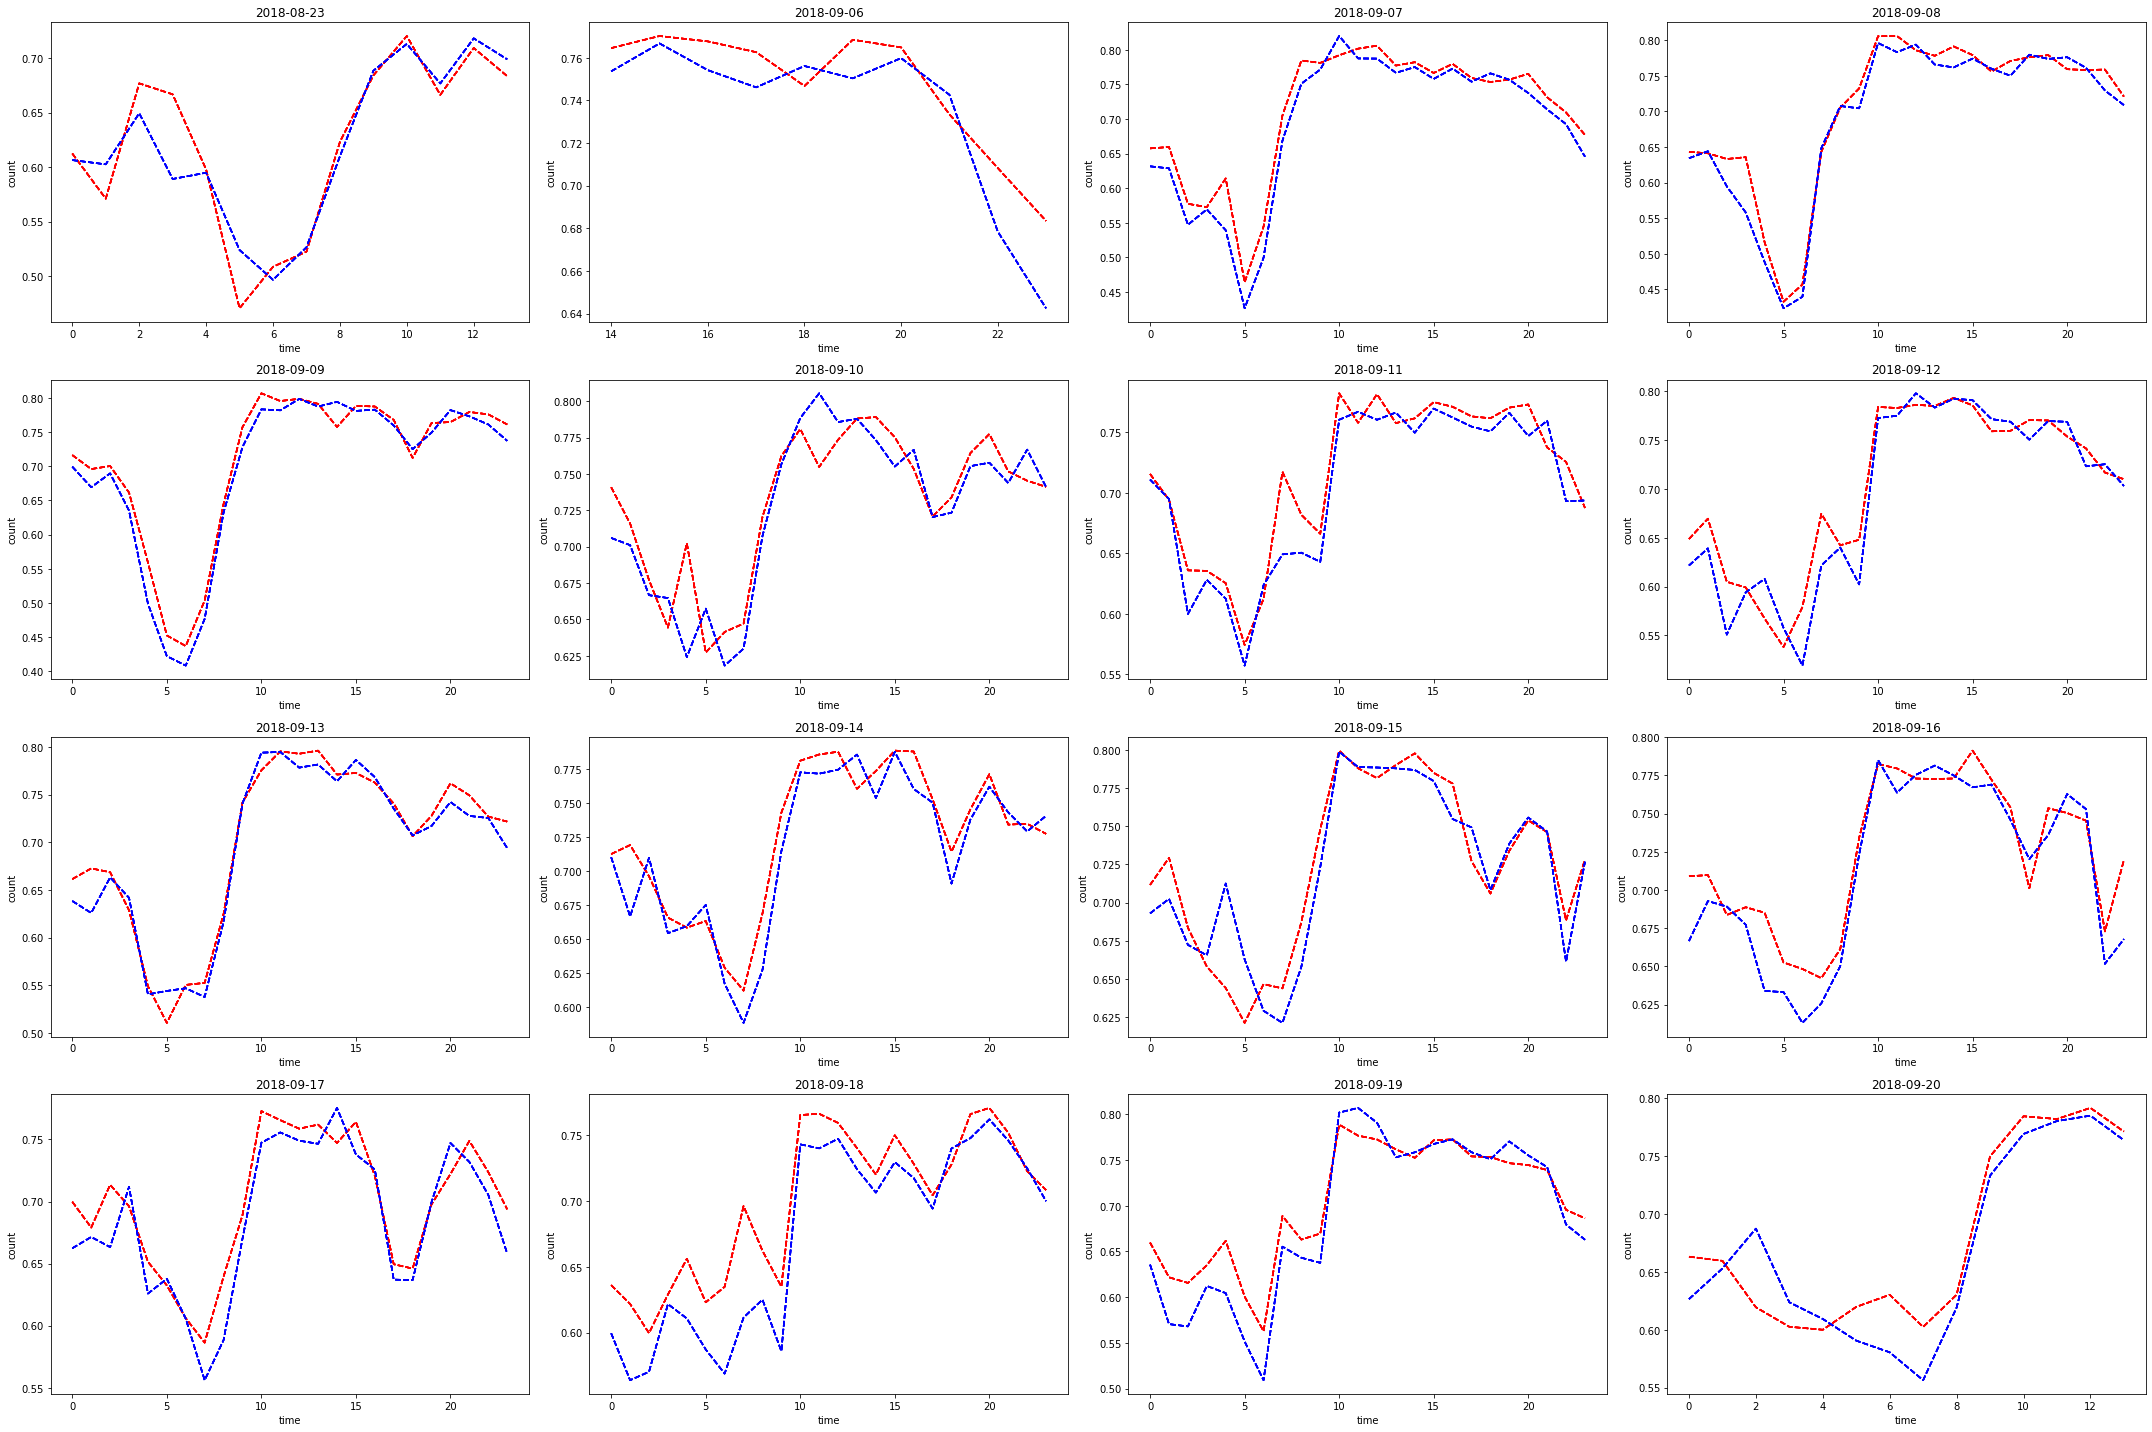

In [23]:
days = data['date'].unique()
days.sort()

data['time'] = pd.to_datetime(data['time'])
data['hours'] = data['time'].dt.hour

fig, axes = plt.subplots(figsize=(30, 20), nrows=4, ncols=4)

for ax, day in zip(axes.flatten(), days):
    ax.plot(data[(data.status == 'done') & (data.date == day) 
                & (data.group == 'test')].groupby('hours').count() / data[(data.date == day) 
                                                                          & (data.group == 'test')].groupby('hours').count(), 'r--', label='Test')
    ax.plot(data[(data.status == 'done') & (data.date == day) 
                & (data.group == 'control')].groupby('hours').count() / data[(data.date == day) 
                                                                          & (data.group == 'control')].groupby('hours').count(), 'b--', label='Control')
    ax.set_xlabel('time')
    ax.set_ylabel('count')
    ax.set_title('{}'.format(day))

fig.tight_layout()

# axes.legend()

## Вывод
Тестовая версия статзначимо лучше, раскатываем алгоритм на всех

# Задание 2

К вам обращается коллега с предложением провести эксперимент с повышеннием надбавок для водителей на заказах эконома для улучшения их исполняемости

Опишите полный цикл обработки такого предложения (какие нужны уточняющие вопросы, целесообразность эксперимента, какие есть риски, дизайн эксперимента, методы анализа и т.д.)

Окей, рассмотрю задачу в вакууме - как будто других задач нет и чисто надо принять решение делать/не делать и если делать, то как

1. Как сейчас определяются надбавки? 
2. От каких факторов зависит исполняемость по нашему опыту? Оптимально ли воздействие именно через надбавки? (мб есть другой фактор, к которому исполняемость более чувствительна и с которым сейчас прям проблемы)
2. Как по нашим ожиданиям надбавки повлияют на факторы исполняемости? От каких факторов она зависит? Водители будут брать заказы быстрее / будут меньше отменять заказов или другие механики?
2. Что еще завязано/контачит с функционалом определения надбавок? Это нужно, чтобы учесть больше возможных последствий и определить всех стейкхолдеров
3. Как выглядят сегменты водителей? Хотим запускать на весь эконом или есть сегменты, где скорее всего эффекта не будет? 
3. Насколько как нам кажется, нужно увеличить надбавку, чтобы увидеть какой-то эффект?
3. Как выглядит экономика поездки? Мы по сути хотим балансировать две метрики - прибыль с одной поездки пойдет вниз, исполняемость должна пойти вверх. Для расчета целесообразности нужно собрать модельку - на основе текущих объемов и структуры маржи, посчитать, насколько должна вырасти исполняемость, чтобы окупить снижение маржинальности
5. Были ли какие-то эксперименты  с ценой для клиента? Если окупить снижение маржинальности можно только нереальной конверсией, то можно прикинуть, не стоит ли часть расходов переложить на клиента и увеличить цену.
6. Если предыдущие два вопроса не ОК - откладываем задачу до лучших времен. Если хотя бы один ОК, то дизайним эксперимент
    
    6.1 Гипотеза: Если повысить надбавки для водителей в экономе, то они будут быстрее принимать заказы / меньше отменять заказы, что повысит исполняемость
    
    6.2 Что делаем в продукте: А/Б 50/50; Контрольная версия - получает надбавки по текущей схеме. Тестовая версия - получает надбавки больше на 10%(например) 
    
    6.3 На ком тестируем: На водителях, работающих в экономе.
    
    6.4 Метрики: Исполняемость (рост до требуемого значения), Среднее время ожидания принятия заказа, Доля отмененных заказов
    
    6.5 Что дальше: Если исполняемость вырастет до нужного значения, то раскатываем на всех. Если нет, то возвращаем на всех старую схему



Какие есть риски:
1. Эксперименты с монетизацией рисковые для репутации - есть вероятность, что одни водители узнают, что другие по более выгодным тарифам ездят
2. Другая проблема экспериментов с монетизацией - если эксперимент не покажет, что большие надбавки работают, то будет демотивация тех, кто попал в тестовую группу. Раньше они зарабатывали больше, сейчас меньше - возможна просадка по ключевым метрикам и отток водителей. Можно сместить разбивку групп с 50/50 к 90/10 или немного поменьше, но это сильно увеличит необходимый объем выборки
2. Может быть негативное влияние на другие классы услуг - например, если водитель одновременно работает в экономе и доставке, то метрики доставки могут начать проседать, т.к. более выгодно брать заказы из эконома
